In [224]:
import os
import sys

sys.path.append(
    "/home/guerrini/sp_validation/cosmo_inference/scripts/"
)

# Trick to have TeX figures
os.environ["LD_LIBRARY_PATH"] = ""
os.environ["CONDA_PREFIX"] = "/home/guerrini/.conda/envs/sp_validation_3.11"

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import chain_postprocessing as cpp

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=7)
g.settings.axes_fontsize=15
g.settings.axes_labelsize=15
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 15

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/glass_mock_chains/"

index = 348
n_contours = 2
roots = [
    f"glass_mock_v6_{i:05d}" for i in range(index, index + n_contours)
]

print(roots)

['glass_mock_v6_00348', 'glass_mock_v6_00349']


In [225]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/{}/samples_{}.txt'.format('/'+root ,root, root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/{}/getdist_{}.paramnames'.format('/'+root, root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

    with open(root_dir + '{}/{}/samples_{}_cell.txt'.format('/'+root ,root, root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/{}/getdist_{}_cell.paramnames'.format('/'+root, root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [226]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/{}/samples_{}.txt'.format(root,root, root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/{}/getdist_{}.txt'.format(root,root, root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/{}/getdist_{}'.format(root,root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

    samples = np.loadtxt(root_dir + '{}/{}/samples_{}_cell.txt'.format(root,root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/{}/getdist_{}_cell.txt'.format(root,root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/{}/getdist_{}_cell'.format(root,root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

2029
/n09data/guerrini/glass_mock_chains/glass_mock_v6_00348/glass_mock_v6_00348/getdist_glass_mock_v6_00348.txt
Removed no burn in
1380
/n09data/guerrini/glass_mock_chains/glass_mock_v6_00348/glass_mock_v6_00348/getdist_glass_mock_v6_00348_cell.txt
Removed no burn in
2071


/n09data/guerrini/glass_mock_chains/glass_mock_v6_00349/glass_mock_v6_00349/getdist_glass_mock_v6_00349.txt
Removed no burn in
1401
/n09data/guerrini/glass_mock_chains/glass_mock_v6_00349/glass_mock_v6_00349/getdist_glass_mock_v6_00349_cell.txt
Removed no burn in


In [227]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label

In [228]:
from astropy.cosmology import Planck18 as planck

Omega_m_fid = planck.Om0
sigma_8_fid = 0.8102
s8_fid = sigma_8_fid * (Omega_m_fid / 0.3)**0.5
h = planck.h
Omega_b_fig = planck.Ob0
n_s_fid = 0.965
print(f"Fiducial values: Omega_m = {Omega_m_fid}, sigma_8 = {sigma_8_fid}, S_8 = {s8_fid}")

markers = {
    "OMEGA_M": Omega_m_fid,
    "SIGMA_8": sigma_8_fid,
    "s_8_input": s8_fid,
    "h0": h,
    "ombh2": Omega_b_fig * h**2,
    "n_s": n_s_fid
}

Fiducial values: Omega_m = 0.30966, sigma_8 = 0.8102, S_8 = 0.8231408713507062


In [229]:
legend_labels = [
     label
    for i in range(index, index + n_contours)
    for label in (
        rf"$\xi_\pm(\vartheta)$, GLASS mock {i}",
        rf"$C_\ell$, GLASS mock {i}"
    )
]

for chain, legend in zip(chains, legend_labels):
    print(f"Chain {legend}:")

    print("Mean values")
    print("S8:", cpp.compute_average(chain, 's_8_input'))
    print("Omega_m:", cpp.compute_average(chain, 'OMEGA_M'))
    print("Sigma_8:", cpp.compute_average(chain, 'SIGMA_8'))

    print("MAP values (1D KDE)")
    print("S8:", cpp.compute_map_1D(chain, 's_8_input'))
    print("Omega_m:", cpp.compute_map_1D(chain, 'OMEGA_M'))
    print("Sigma_8:", cpp.compute_map_1D(chain, 'SIGMA_8'))

    print("MAP values (2D KDE)")
    S8_map, Omega_m_map = cpp.compute_map_2D(chain, 's_8_input', 'OMEGA_M')
    print("S8:", S8_map)
    print("Omega_m:", Omega_m_map)


""" #Plot all parameters
g.triangle_plot(
    chains,
    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    markers=markers
)

plt.show() """

Chain $\xi_\pm(\vartheta)$, GLASS mock 348:
Mean values
S8: 0.8032002645579881
Omega_m: 0.32455237391423253
Sigma_8: 0.7972635140121388
MAP values (1D KDE)
S8: 0.7997896669571766
Omega_m: 0.2949504200458696
Sigma_8: 0.7476350440729322
MAP values (2D KDE)
S8: 0.8060513027919459
Omega_m: 0.28955600859587055
Chain $C_\ell$, GLASS mock 348:
Mean values
S8: 0.8123316350144142
Omega_m: 0.30509291398699623
Sigma_8: 0.8612243038493412
MAP values (1D KDE)
S8: 0.8303505144885452
Omega_m: 0.22239719739242508
Sigma_8: 0.7377297014094878
MAP values (2D KDE)
S8: 0.8378859105457945
Omega_m: 0.21434605148445474
Chain $\xi_\pm(\vartheta)$, GLASS mock 349:
Mean values
S8: 0.8213231085415501
Omega_m: 0.36663713268885356
Sigma_8: 0.7651860920397948
MAP values (1D KDE)
S8: 0.8028626943375338
Omega_m: 0.3576321830592363
Sigma_8: 0.722398322012948
MAP values (2D KDE)
S8: 0.7979085208930579
Omega_m: 0.35839166692527313
Chain $C_\ell$, GLASS mock 349:
Mean values
S8: 0.8262479813112372
Omega_m: 0.3240032452048

" #Plot all parameters\ng.triangle_plot(\n    chains,\n    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],\n    legend_labels=legend_labels,\n    legend_loc='upper right',\n    filled=True,\n    markers=markers\n)\n\nplt.show() "

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


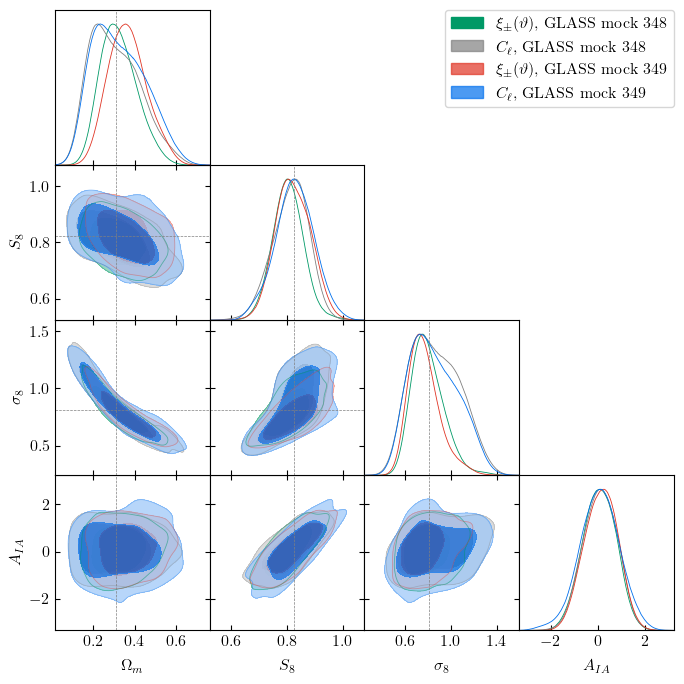

In [230]:
#Plot only cosmological parameters

g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input', 'SIGMA_8', 'a'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    markers=markers
)


plt.show()

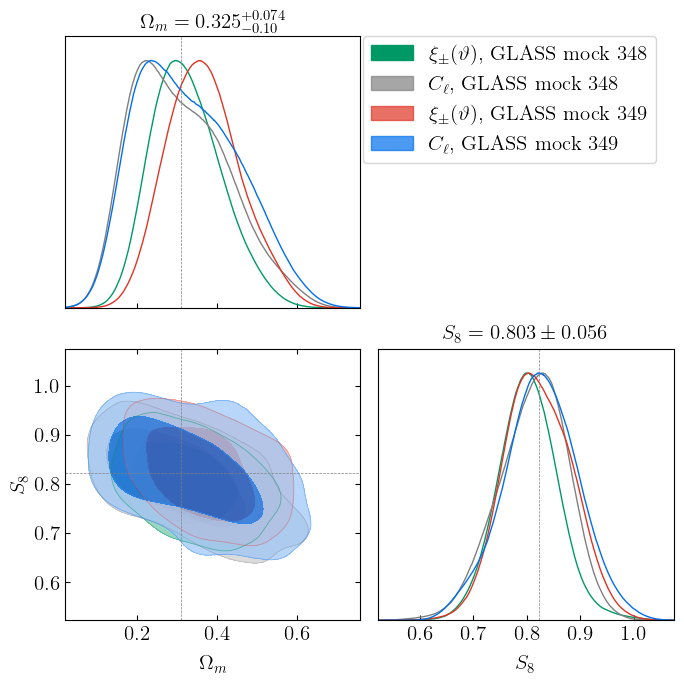

In [231]:
preliminary_watermark = False
#Plot S8 Omega_m only
g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    title_limit=1,
    markers=markers
)

if preliminary_watermark:
    plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=150, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330)

plt.show()